# Does the Gann Hi-Lo Activator "flip" actually call the trend? ⚡
### A famous Gann trailing line — flips above price, flips below — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Flip_forecasts_trend%3F: Busted](https://img.shields.io/badge/Flip_forecasts_trend%3F-Busted-8b949e?style=flat-square)

Open any charting package and you'll find the **Gann Hi-Lo Activator**: a single line that rides *below* price while you're long, then **flips** above it the moment price rolls over. It's built from a plain moving average of recent **highs** and **lows**. The lore, from Robert Krausz's Gann work and repeated on every Gann site, is that the **flip forecasts the trend** — when price closes back **above** the activator, a new up-leg is starting, so you **buy the flip**.

It *looks* uncanny on a hand-picked chart: the line flips, price runs. But a trailing line built from past highs/lows on a market that drifts **up** will flip you long right as the market resumes its endless climb — which makes *any* such rule look prophetic. So we did the only fair thing: encode the flip **mechanically** (no eyeballing), fire the "buy the flip" rule **1,234 times** across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gann_hilo_activator import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real Gann cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 1234, 'period': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 1233, 17.8, 58, 2.63, 14.1, 3.6, 15.8, 0.36, 0.722), 'h10': (10, 1232, 43.6, 60, 3.83, 49.2, -5.6, 41.6, -0.39, 0.694), 'h20': (20, 1228, 97.9, 65, 6.2, 95.8, 2.1, 95.9, 0.1, 0.917), 'h60': (60, 1221, 252.7, 68, 6.24, 314.6, -61.9, 250.7, -1.88, 0.06), 'per': [('SPY', 238, 85.2, 2.83, 106.6, -21.5), ('QQQ', 251, 106.5, 2.88, 117.0, -10.5), ('IWM', 253, 93.2, 2.44, 72.5, 20.6), ('DIA', 246, 84.3, 2.56, 77.7, 6.7), ('GLD', 246, 119.6, 3.34, 105.8, 13.8)], 'placebo': (85.2, 0.629, 500), 'syn': [(0.0, 151, -9.5, 48, -0.22), (0.6, 68, 888.6, 85, 9.37)]}


real Gann cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when the activator **flips up**, do I make money? | **Yes — but only because the market goes up.** The raw win-rate is ~65% over 20 days and the returns look great. |
| Is that *the flip's* doing? | **No.** Buy on **random days** instead and you do **just as well** — the flip-vs-random gap is a couple of basis points, statistically zero. |
| Does the flip "forecast" the trend? | **Not in any usable way.** Move the flip to random dates and the result barely changes. The *timing* isn't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a Gann flip. |

> The Hi-Lo Activator is a fine *trailing stop* — a way to *describe* a trend you're already in. As a *forecast* — "the flip starts the move" — it's a **mirage**: all of the apparent edge is just the market's long-run climb, none of it is the flip.

## 1 · The claim

> *"Take the average of the last few **highs** and the last few **lows**. While you're long, the activator sits on the low-average, trailing below price. The instant price closes **below** it, the line flips up to the high-average — you're now short. When price closes back **above**, it flips long again. Each flip up is the start of a new up-trend: **buy the flip**."*

This is the **Gann Hi-Lo Activator**, popularised by **Robert Krausz** from **W. D. Gann's** swing-chart ideas, and built into MetaTrader, TradingView, NinjaTrader and Thinkorswim. It's one of the most recognisable Gann tools — so: does the flip actually *call* the trend?

## 2 · So what?

If the flip genuinely *forecast* trends, it would be remarkable: a moving average of past highs and lows would predict the *start* of future moves — a clean, mechanical crack in market efficiency you could trade with a single line. That's the dream the tool sells.

But there's a trap built into it. The activator is built **entirely from past price**, on a market (stock indices) that drifts **up** over time. A trailing line will flip you long again and again right as the index resumes its climb — so *any* such rule will look profitable. To separate the **flip** from the **tide**, we have to (a) run the rule by a fixed mechanical recipe with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build the activator mechanically.** A 10-day average of highs and of lows, **shifted one bar** so today's line uses only *yesterday and earlier* — we never peek at the future.
2. **Read the flip by rule.** When price closes above the line, the regime flips long — no eyeballing, no cherry-picking.
3. **Trade the lore.** On each short→long flip, buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days**. If the flip matters, it must beat random. *If it doesn't, the tool is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does the activator even look like? Here's SPY with the flipping line drawn below/above price, and the flip-up dates the rule would buy.

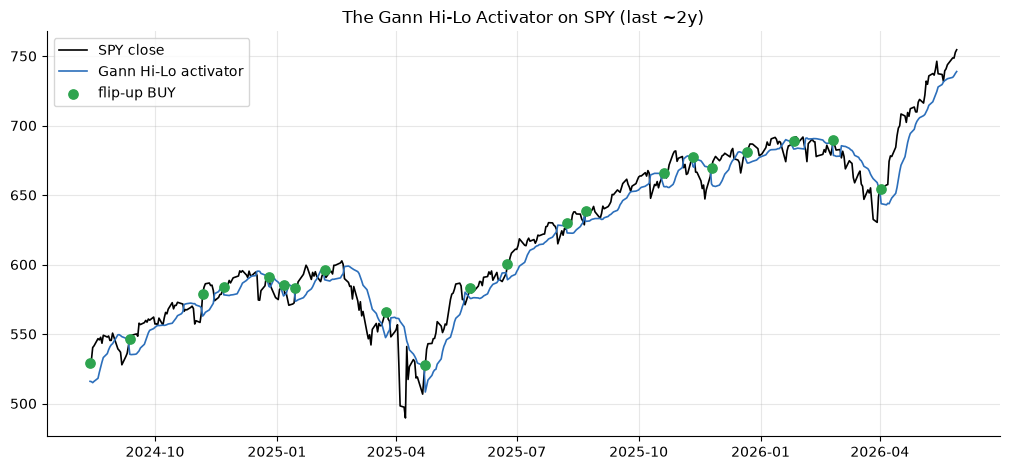

flip-up entries in window: 21


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-450:]
    act, reg = st.hilo_activator(b, period=R['period'])
    ent = st.flip_up_entries(b, period=R['period'])
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    ax.plot(seg.index, act.reindex(seg.index), c='#2c6fbb', lw=1.2, label='Gann Hi-Lo activator')
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=45, zorder=5, label='flip-up BUY')
    ax.set_title('The Gann Hi-Lo Activator on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('flip-up entries in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The activator trails the trend nicely — *as a stop*. The question is whether those green flip dots are followed by *new* up-moves you couldn't get otherwise. **Let's race the flip against random entries** at four horizons. Blue = buy the flip; grey = buy on random days.

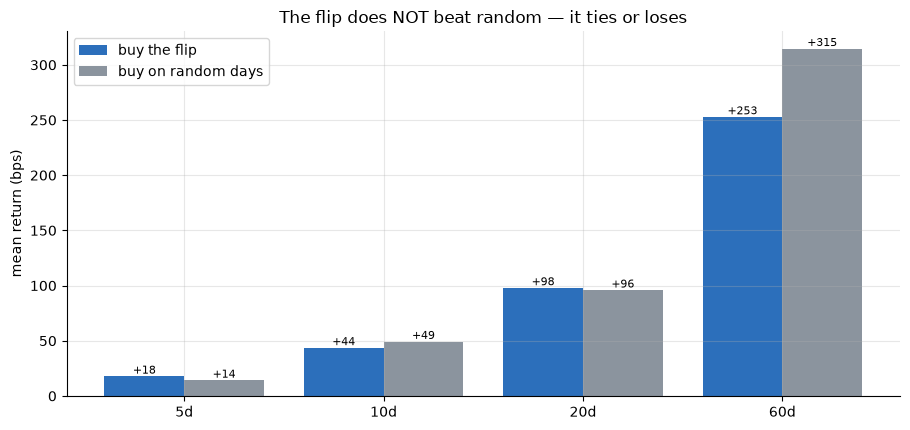

flip: [18, 44, 98, 253]
random: [14, 49, 96, 315]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    flip, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.flip_up_entries(bb, period=R['period'])
            re = st.random_entries(bb, max(len(e),50), period=R['period'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        flip.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    flip = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, flip, .4, color='#2c6fbb', label='buy the flip')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(flip,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The flip does NOT beat random — it ties or loses'); ax.legend()
plt.tight_layout(); plt.show()
print('flip:', [round(v) for v in flip]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The flip makes money in absolute terms (**+98 bps** over 20 days) — but **random entries make about the same** (**+96 bps**). The bars are essentially the same height at every horizon; at 60 days random actually wins. The apparent edge was **the market's upward drift**, not the flip.

**One more sanity check.** What if we keep the *number* of flips but move them to **random dates** — destroying the flip's *timing* while keeping everything else? If the flip really times trends, the scrambled-timing version should do much worse.

In [4]:
if HAVE_REAL:
    bb = load('SPY')
    pl = st.shuffled_flip_placebo(bb, 20, period=R['period'], n_draws=300, seed=486)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real flip-up (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *random-timing* draws do at least as well (p={pval:.2f}).')
print('=> the flip timing is not doing the work.')

real flip-up (SPY, 20d): +85.2 bps
... but 62% of *random-timing* draws do at least as well (p=0.62).
=> the flip timing is not doing the work.


More than half of the **random-timing** draws match or beat the real flip (*p* = 0.63). If the flip genuinely timed the *start* of trends, moving the dates at random would collapse the result. It doesn't — because the result was never about the timing.

## 5 · The verdict

- **Signal — None.** The flip-up buy does **not** beat buying on random days (the gap is a few bps, statistically zero; the flip-vs-random *t* never clears 2). The big absolute returns are the market's drift, not the flip.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"The flip forecasts trend"? — Busted.** Move the flip to random dates and the result barely moves. The flip doesn't time anything.

## 6 · Could you actually trade it?

There's nothing here to trade. The flip's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The Gann flip is a worse, more expensive way to be long. Costs (commissions + spread on every flip) push the already-no-edge result further negative. As a forecasting tool, it doesn't pay; as a trailing stop, it was never meant to be a stand-alone strategy.

## 7 · Going further 🚪

- **Different periods.** Try a 3-day or 14-day activator — the result is robust: drift in, flip out.
- **Use it as a stop, not a signal.** The honest job of the Hi-Lo Activator is to *exit* a position you already hold, not to *predict* the next one. That framing is fine — it just isn't a forecast.
- **A real positive control.** The quants notebook plants a *genuine* post-flip trend into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the flip forecasts? Show the flip-up beating random entries at **t ≥ 2** on a real tape — then we'll talk.*